In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from assignments.helpers import preprocess_data
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV, KFold

In [2]:
preprocessed_data = preprocess_data()
preprocessed_data.shape

(1460, 20)

In [3]:
preprocessed_data.head()

,LotArea,LotConfig,Neighborhood,BldgType,OverallQual,YearBuilt,MasVnrArea,BsmtExposure,BsmtFinType1,TotalBsmtSF,HeatingQC,CentralAir,GrLivArea,FullBath,Fireplaces,FireplaceQu,GarageFinish,GarageCars,SaleCondition,SalePrice
0,8450,Inside,CollgCr,1Fam,7,2003,196.0,No,GLQ,856,Ex,Y,1710,2,0,NaN,RFn,2,Normal,208500
1,9600,FR2,Veenker,1Fam,6,1976,0.0,Gd,ALQ,1262,Ex,Y,1262,2,1,TA,RFn,2,Normal,181500
2,11250,Inside,CollgCr,1Fam,7,2001,162.0,Mn,GLQ,920,Ex,Y,1786,2,1,TA,RFn,2,Normal,223500
3,9550,Corner,Crawfor,1Fam,7,1915,0.0,No,ALQ,756,Gd,Y,1717,1,1,Gd,Unf,3,Abnorml,140000
4,14260,FR2,NoRidge,1Fam,8,2000,350.0,Av,GLQ,1145,Ex,Y,2198,2,1,TA,RFn,3,Normal,250000


In [4]:
# Dropping the single record with a genuinely missing BsmtExposure (basement exists, value missing)
genuine_missing = preprocessed_data["BsmtExposure"].isnull() & (preprocessed_data["TotalBsmtSF"] > 0)
print("Rows dropped:", genuine_missing.sum())
preprocessed_data = preprocessed_data[~genuine_missing].copy()
print(preprocessed_data.shape)

Rows dropped: 1
(1459, 20)


In [5]:
# Drop the two known anomalous records: very large, top-quality houses with implausibly low prices
anomalous = (preprocessed_data["GrLivArea"] > 4000) & (preprocessed_data["SalePrice"] < 300000)
print("Rows dropped:", anomalous.sum())          # expected: 2
preprocessed_data = preprocessed_data[~anomalous].copy()
print(preprocessed_data.shape)                    # expected: (1457, 20)

Rows dropped: 2
(1457, 20)


In [6]:
# Drop extreme LotArea records (huge lots with ordinary prices, no matching price signal)
extreme_lot = preprocessed_data["LotArea"] > 100000
print("Rows dropped:", extreme_lot.sum())          # expected: 4
preprocessed_data = preprocessed_data[~extreme_lot].copy()
print(preprocessed_data.shape)                      # expected: (1453, 20)

Rows dropped: 4
(1453, 20)


In [7]:
price_bins = pd.qcut(preprocessed_data["SalePrice"], q=5, labels=False)

In [8]:
train_data, test_data = train_test_split(
    preprocessed_data,
    test_size=0.25,
    random_state=42,
    stratify=price_bins
)

In [9]:
# let's find the shape of our datasets
print(train_data.shape)
print(test_data.shape) 

(1089, 20)
(364, 20)


In [10]:
# Column groups
median_impute_col = ["MasVnrArea"]
none_impute_ordinal_cols = ["BsmtExposure", "BsmtFinType1", "FireplaceQu", "GarageFinish"]
ordinal_only_col = ["HeatingQC"]
passthrough_cols = ["LotArea", "OverallQual", "YearBuilt", "TotalBsmtSF",
                     "GrLivArea", "FullBath", "Fireplaces", "GarageCars"]
nominal_cols = ["Neighborhood", "CentralAir", "LotConfig", "BldgType", "SaleCondition"]


In [11]:
# Category orders, these lists show the ordinal categories, add 'None' for missing features to make a new category
none_impute_ordinal_orders = [
    ["None", "No", "Mn", "Av", "Gd"],                    # BsmtExposure
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],  # BsmtFinType1
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],              # FireplaceQu
    ["None", "Unf", "RFn", "Fin"],                       # GarageFinish
]
heatingqc_order = [["Po", "Fa", "TA", "Gd", "Ex"]]

In [12]:
# Sub-pipelines
median_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

none_ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OrdinalEncoder(categories=none_impute_ordinal_orders))
])

heatingqc_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(categories=heatingqc_order))
])

onehot_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", sparse_output=False))
])


In [13]:
# ColumnTransformer combines all of the sub-pipelines
preprocessor = ColumnTransformer([
    ("median_impute", median_pipeline, median_impute_col),
    ("none_ordinal", none_ordinal_pipeline, none_impute_ordinal_cols),
    ("heatingqc", heatingqc_pipeline, ordinal_only_col),
    ("passthrough", "passthrough", passthrough_cols),
    ("onehot", onehot_pipeline, nominal_cols),
])

In [14]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("scaling", StandardScaler())
])

In [15]:
X_train_raw = train_data.drop(columns=["SalePrice"])
y_train = train_data["SalePrice"]
X_test_raw = test_data.drop(columns=["SalePrice"])
y_test = test_data["SalePrice"]

In [16]:
X_train_unscaled = full_pipeline.named_steps["preprocessing"].fit_transform(X_train_raw)
X_test_unscaled = full_pipeline.named_steps["preprocessing"].transform(X_test_raw)

In [17]:
type(X_train_unscaled)

numpy.ndarray

### **Step 1: Generating Polynomial Features**

Polynomial features are generated **only from the 8 continuous numerical predictors** 
1. `LotArea` 
2. `YearBuilt`
3. `MasVnrArea`
4. `TotalBsmtSF`
5. `GrLivArea`
6. `FullBath`
7. `Fireplaces`
8. `GarageCars`

**Why this approach:** squaring or multiplying dummy variables (0/1) is mathematically uninformative.
**Squaring** a binary value returns the same value like, `dummy² = dummy`.
Multiplying two different one-hot dummies from the same categorical is always 0.
Including these would inflate the feature count substantially without genuine new features.

**Polynomial model** focuses on the continuous features, where non-linear and interaction become literally meaningful.

In [18]:
feature_names = full_pipeline.named_steps["preprocessing"].get_feature_names_out()

continuous_cols = ["LotArea", "YearBuilt", "MasVnrArea", "TotalBsmtSF",
                    "GrLivArea", "FullBath", "Fireplaces", "GarageCars"]

continuous_indices = [i for i, name in enumerate(feature_names)
                       if name.split("__")[-1] in continuous_cols]

X_train_continuous = X_train_unscaled[:, continuous_indices]
X_test_continuous = X_test_unscaled[:, continuous_indices]

print("Selected features:", [feature_names[i] for i in continuous_indices])
print("X_train_continuous shape:", X_train_continuous.shape)
print("X_test_continuous shape:", X_test_continuous.shape)

Selected features: ['median_impute__MasVnrArea', 'passthrough__LotArea', 'passthrough__YearBuilt', 'passthrough__TotalBsmtSF', 'passthrough__GrLivArea', 'passthrough__FullBath', 'passthrough__Fireplaces', 'passthrough__GarageCars']
X_train_continuous shape: (1089, 8)
X_test_continuous shape: (364, 8)


In [19]:
X_train_continuous[:1,:]

array([[0.000e+00, 7.711e+03, 1.977e+03, 1.440e+03, 1.440e+03, 2.000e+00,
        0.000e+00, 0.000e+00]])

In [20]:
X_train_continuous

array([[0.0000e+00, 7.7110e+03, 1.9770e+03, ..., 2.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.9100e+02, 1.0197e+04, 1.9610e+03, ..., 1.0000e+00, 1.0000e+00,
        2.0000e+00],
       [0.0000e+00, 1.0634e+04, 1.9530e+03, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       ...,
       [0.0000e+00, 5.3300e+03, 1.9400e+03, ..., 1.0000e+00, 0.0000e+00,
        0.0000e+00],
       [0.0000e+00, 9.6380e+03, 1.9190e+03, ..., 2.0000e+00, 1.0000e+00,
        1.0000e+00],
       [6.6400e+02, 1.3688e+04, 2.0030e+03, ..., 2.0000e+00, 2.0000e+00,
        3.0000e+00]], shape=(1089, 8))

### **2. Report**

**1. Number of predictors:**

**2. Number of polynomial features generated at each degree:** 

**3. Examples of individual-power terms:**

**4. Examples of cross or interaction terms:**

### **3. Develop a polynomial regression model for each degree:**

In [21]:
for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly.fit(X_train_continuous)
    print(f"Degree {degree}: {len(poly.get_feature_names_out())} features generated")

Degree 2: 44 features generated
Degree 3: 164 features generated
Degree 4: 494 features generated


In [22]:
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x0^2', 'x0 x1',
       'x0 x2', 'x0 x3', 'x0 x4', 'x0 x5', 'x0 x6', 'x0 x7', 'x1^2',
       'x1 x2', 'x1 x3', 'x1 x4', 'x1 x5', 'x1 x6', 'x1 x7', 'x2^2',
       'x2 x3', 'x2 x4', 'x2 x5', 'x2 x6', 'x2 x7', 'x3^2', 'x3 x4',
       'x3 x5', 'x3 x6', 'x3 x7', 'x4^2', 'x4 x5', 'x4 x6', 'x4 x7',
       'x5^2', 'x5 x6', 'x5 x7', 'x6^2', 'x6 x7', 'x7^2', 'x0^3',
       'x0^2 x1', 'x0^2 x2', 'x0^2 x3', 'x0^2 x4', 'x0^2 x5', 'x0^2 x6',
       'x0^2 x7', 'x0 x1^2', 'x0 x1 x2', 'x0 x1 x3', 'x0 x1 x4',
       'x0 x1 x5', 'x0 x1 x6', 'x0 x1 x7', 'x0 x2^2', 'x0 x2 x3',
       'x0 x2 x4', 'x0 x2 x5', 'x0 x2 x6', 'x0 x2 x7', 'x0 x3^2',
       'x0 x3 x4', 'x0 x3 x5', 'x0 x3 x6', 'x0 x3 x7', 'x0 x4^2',
       'x0 x4 x5', 'x0 x4 x6', 'x0 x4 x7', 'x0 x5^2', 'x0 x5 x6',
       'x0 x5 x7', 'x0 x6^2', 'x0 x6 x7', 'x0 x7^2', 'x1^3', 'x1^2 x2',
       'x1^2 x3', 'x1^2 x4', 'x1^2 x5', 'x1^2 x6', 'x1^2 x7', 'x1 x2^2',
       'x1 x2 x3', 'x1 x2 x4', 'x1 x2 x

### **Step 5: Degree Selection via K-Fold Cross-Validation**

**Pipeline:** 

`PolynomialFeatures` → `StandardScaler` → `LinearRegression` is wrapped in `GridSearchCV`.

**Testing degrees:**

2, 3, and 4 

**k-fold cross-validation:**

`GridSearchCV` performs k-fold cross-validation (k=5). 

**What happens inside `GridSearchCV`**

`GridSearchCV` evaluates each candidate degree by the given criterion, that is **R2-Score**. It selects the degree with the best average cross-validation score.
To avoid data leakage problem, only training data has been used in this process.

**`Scaling` is applied after polynomial expansion:**

The interaction and power terms must be generated from the original, unscaled feature values, just to keep them mathematically meaningful.

In [23]:
poly_pipeline = Pipeline([
    ("poly_features", PolynomialFeatures(include_bias=False)),
    ("scaling", StandardScaler()),
    ("model", LinearRegression())
])

param_grid = {"poly_features__degree": [2, 3, 4]}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    poly_pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring="r2",
    return_train_score=True,
    refit=True,
    verbose=1
)

grid_search.fit(X_train_continuous, y_train)

print("Best degree:", grid_search.best_params_)
print("Best CV R² score:", grid_search.best_score_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best degree: {'poly_features__degree': 2}
Best CV R² score: 0.8306907155300391


In [24]:
grid_search.__dir__()

['scoring',
 'estimator',
 'n_jobs',
 'refit',
 'cv',
 'verbose',
 'pre_dispatch',
 'error_score',
 'return_train_score',
 'param_grid',
 '_checked_cv_orig',
 'n_splits_',
 'multimetric_',
 'best_index_',
 'best_score_',
 'best_params_',
 'best_estimator_',
 'refit_time_',
 'scorer_',
 'cv_results_',
 '__module__',
 '__annotations__',
 '__doc__',
 '_parameter_constraints',
 '__init__',
 '_run_search',
 '__abstractmethods__',
 '_abc_impl',
 '__sklearn_tags__',
 'score',
 '_wrap_namespace_error',
 'predict',
 'n_features_in_',
 '_check_refit_for_multimetric',
 '_select_best_index',
 '_get_scorers',
 '_check_scorers_accept_sample_weight',
 '_check_input_parameters',
 '_get_routed_params_for_fit',
 'fit',
 '_format_results',
 'get_metadata_routing',
 '_sk_visual_block_',
 '__dict__',
 '__weakref__',
 '__new__',
 '__repr__',
 '__hash__',
 '__str__',
 '__getattribute__',
 '__setattr__',
 '__delattr__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__reduce_ex__',
 '__re

In [25]:
grid_search.cv_results_

{'mean_fit_time': array([0.01101322, 0.02491035, 0.07563157]),
 'std_fit_time': array([0.00307546, 0.00986909, 0.00649785]),
 'mean_score_time': array([0.00251141, 0.0031868 , 0.00561814]),
 'std_score_time': array([0.00140664, 0.00299814, 0.00529912]),
 'param_poly_features__degree': masked_array(data=[2, 3, 4],
              mask=[False, False, False],
        fill_value=999999),
 'params': [{'poly_features__degree': 2},
  {'poly_features__degree': 3},
  {'poly_features__degree': 4}],
 'split0_test_score': array([  0.83738616,   0.76537031, -76.49624303]),
 'split1_test_score': array([ 7.99222639e-01,  3.32351529e-01, -3.46468273e+02]),
 'split2_test_score': array([  0.87010577,   0.82600882, -50.94558333]),
 'split3_test_score': array([   0.78896918,    0.71248684, -141.43092693]),
 'split4_test_score': array([  0.85776984,   0.74332287, -56.82583381]),
 'mean_test_score': array([   0.83069072,    0.67590808, -134.43337201]),
 'std_test_score': array([3.18200584e-02, 1.75754139e-01,

In [26]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_poly_features__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.011013,0.003075,0.002511,0.001407,2,{'poly_features__degree': 2},0.837386,0.799223,0.870106,0.788969,...,0.830691,0.031820,1,0.873762,0.874650,0.868067,0.880077,0.869596,0.873230,0.004220
1,0.024910,0.009869,0.003187,0.002998,3,{'poly_features__degree': 3},0.765370,0.332352,0.826009,0.712487,...,0.675908,0.175754,2,0.907976,0.912210,0.906508,0.915863,0.911656,0.910842,0.003309
2,0.075632,0.006498,0.005618,0.005299,4,{'poly_features__degree': 4},-76.496243,-346.468273,-50.945583,-141.430927,...,-134.433372,110.776908,3,0.950741,0.954958,0.951239,0.958274,0.950465,0.953135,0.003039


In [27]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results_summary = cv_results[[
    "param_poly_features__degree",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].rename(columns={
    "param_poly_features__degree": "Degree",
    "mean_train_score": "Mean Train R²",
    "mean_test_score": "Mean Validation R²",
    "std_test_score": "Std Validation R²"
})

cv_results_summary

,Degree,Mean Train R²,Mean Validation R²,Std Validation R²
0,2,0.873230,0.830691,0.031820
1,3,0.910842,0.675908,0.175754
2,4,0.953135,-134.433372,110.776908


### 6. Let's Test the best model

For the selected model, report: 

1. Intercept 

2. Coefficients of all individual-power terms; 

3. Coefficients of all interaction terms; 

4. Training and test MAE 

5. Training and test RMSE 

6. Training and test R2

In [28]:
best_poly_model = grid_search.best_estimator_

poly_train_preds = best_poly_model.predict(X_train_continuous)
poly_test_preds = best_poly_model.predict(X_test_continuous)

print("Train R²:", r2_score(y_train, poly_train_preds))
print("Test R²:", r2_score(y_test, poly_test_preds))
print("Train MAE:", mean_absolute_error(y_train, poly_train_preds))
print("Test MAE:", mean_absolute_error(y_test, poly_test_preds))
print("Train RMSE:", root_mean_squared_error(y_train, poly_train_preds))
print("Test RMSE:", root_mean_squared_error(y_test, poly_test_preds))

Train R²: 0.870809085636175
Test R²: 0.8558328998271231
Train MAE: 19894.704675811292
Test MAE: 21314.34399851643
Train RMSE: 28022.828238709135
Test RMSE: 31614.770031719712


In [29]:
best_poly_model.named_steps

{'poly_features': PolynomialFeatures(include_bias=False),
 'scaling': StandardScaler(),
 'model': LinearRegression()}

In [31]:
best_poly_model.named_steps["poly_features"]

PolynomialFeatures(include_bias=False)

In [32]:
coef_terms_values = best_poly_model.named_steps["model"].coef_

In [33]:
coef_terms_names = best_poly_model.named_steps["poly_features"].get_feature_names_out()

In [34]:
coef_table = pd.DataFrame({
    "Term": coef_terms_names,
    "Coefficient": coef_terms_values
})

In [35]:
coef_table.head()

,Term,Coefficient
0,x0,-613219.749514
1,x1,-88111.938694
2,x2,-542356.107696
3,x3,-874148.308540
4,x4,116953.255075


### 7. Present appropriate visualizations, including: 

1. Training and validation error against polynomial degree 

2. Actual versus predicted values 

3. Residuals versus predicted values 

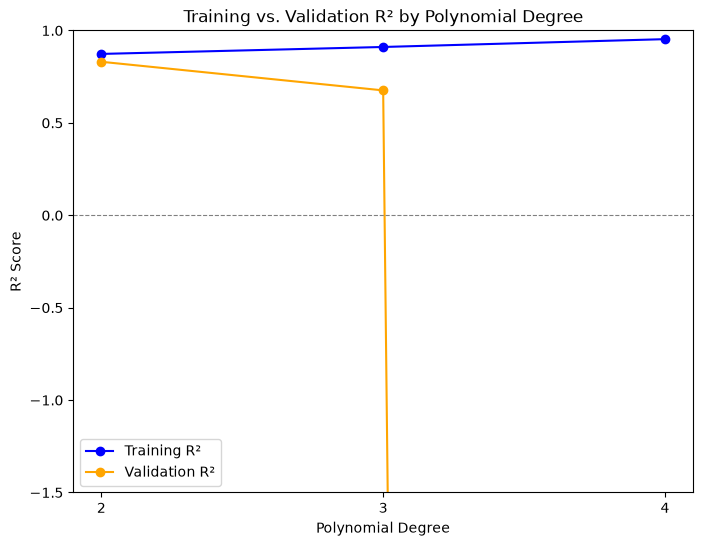

In [36]:
degrees = [2, 3, 4]
train_scores = cv_results_summary["Mean Train R²"].values
val_scores = cv_results_summary["Mean Validation R²"].values

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(degrees, train_scores, marker="o", label="Training R²", color="blue")
ax.plot(degrees, val_scores, marker="o", label="Validation R²", color="orange")
ax.set_xticks(degrees)
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("R² Score")
ax.set_title("Training vs. Validation R² by Polynomial Degree")
ax.set_ylim(-1.5, 1.0)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.legend()
plt.show()